# Phase 3 RF-QRC ring calibration sweep

Purpose: run a small, bounded hyperparameter sweep for the RF-QRC ring variant while preserving the original Phase 2 forecast-aware regime-layer evaluation.

This notebook only does what is needed:

1. Find the repo root and force all outputs to root-level `results/`.
2. Load the Phase 2 SPY/VIX dataset.
3. Build RF-QRC `level_rate` inputs once.
4. Sweep `leak` and `ridge_alpha` for the RF-QRC **second-encode ring** variant only.
5. Evaluate both raw forecast diagnostics and forecast-aware regime-layer metrics.
6. Save sweep tables and figures.

Default sweep size: **5 leaks × 4 ridge values = 20 configs**. It should be reasonable for a dog-walk run. The expensive feature map is rebuilt only once per leak; ridge readouts are cheap.


In [1]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import time
import subprocess
import importlib.util
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import f1_score, mean_squared_error, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

NOTEBOOK_START = time.time()

def find_repo_root() -> Path:
    """Find qpitome-qrc-volatility repo root from notebooks/, repo root, or a child folder."""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if p.name == "qpitome-qrc-volatility" and (p / "scripts").exists() and (p / "src").exists():
            return p

    # Fallback: search nearby likely parent folders, not the whole disk.
    likely_starts = [
        cwd,
        cwd.parent,
        Path.home() / "Documents",
        Path.home() / "Workspace",
    ]
    for start in likely_starts:
        if not start.exists():
            continue
        matches = list(start.rglob("qpitome-qrc-volatility"))
        for m in matches:
            if (m / "scripts").exists() and (m / "src").exists():
                return m.resolve()

    raise RuntimeError("Could not find repo root named qpitome-qrc-volatility.")

ROOT = find_repo_root()
os.chdir(ROOT)

TABLE_DIR = ROOT / "results" / "tables"
FIG_DIR = ROOT / "results" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if ROOT.name != "qpitome-qrc-volatility":
    raise RuntimeError(f"Unexpected repo root: {ROOT}")

print("Repo root:", ROOT)
print("Working directory:", Path.cwd())
print("Tables:", TABLE_DIR)
print("Figures:", FIG_DIR)

# Hard guard against accidental notebooks/results pollution.
bad_results = ROOT / "notebooks" / "results"
if bad_results.exists():
    print("WARNING: stray notebooks/results exists. It is not used by this notebook:", bad_results)


Repo root: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility
Working directory: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility
Tables: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables
Figures: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures


In [2]:
# Import the existing RF-QRC implementation without relying on package installation.
rfqrc_path = ROOT / "scripts" / "run_phase3_rf_qrc_tail_probe.py"
if not rfqrc_path.exists():
    raise FileNotFoundError(f"Missing RF-QRC script: {rfqrc_path}")

spec = importlib.util.spec_from_file_location("rfqrc_tail_probe", rfqrc_path)
rfqrc = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(rfqrc)

print("Loaded:", rfqrc_path)
print("RF-QRC seed:", rfqrc.SEED)


Loaded: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/scripts/run_phase3_rf_qrc_tail_probe.py
RF-QRC seed: 42


## 1. Load dataset and rebuild Phase 2 stress timeline

This uses the same dataset and stress-confirmation logic as the original Phase 2 forecast-aware regime layer. If the processed dataset is missing, the notebook runs the dataset builder once.


In [3]:
# Ensure dataset exists.
try:
    data_path = rfqrc.find_dataset(ROOT, explicit=None)
except FileNotFoundError:
    print("Processed dataset missing. Running scripts/prepare_phase2_spy_vix_dataset.py ...")
    subprocess.run([sys.executable, "scripts/prepare_phase2_spy_vix_dataset.py"], check=True)
    data_path = rfqrc.find_dataset(ROOT, explicit=None)

print("Dataset:", data_path)

# Load matrix for RF-QRC.
X, y, split, dates, feature_cols = rfqrc.load_matrix(data_path, rfqrc.TARGET_COL)
dates = pd.to_datetime(dates)

print("X:", X.shape)
print("y:", y.shape)
print("split counts:", pd.Series(split).value_counts().to_dict())
print("date range:", dates.min(), "->", dates.max())
print("features:", len(feature_cols))


Dataset: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/data/processed/phase2_spy_vix_volatility.csv
X: (7775, 38)
y: (7775,)
split counts: {'train': 5420, 'val': 1219, 'test': 1136}
date range: 1993-04-27 00:00:00 -> 2024-03-15 00:00:00
features: 38


In [4]:
# Rebuild original Phase 2 stress timeline for forecast-aware regime-layer evaluation.
sys.path.insert(0, str(ROOT / "src"))

from qpitome_qrc.data.loaders import load_phase2_volatility_data
from qpitome_qrc.data.splits import chronological_tabular_split

target = "future_rv_20d"

def make_stress_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy().reset_index(drop=True)
    out["date"] = pd.to_datetime(out["date"])
    out["spy_selloff_stress"] = -out["spy_log_return"]
    out["spy_oc_selloff_stress"] = -out["spy_log_oc_return"]
    out["drawdown_stress"] = -out["spy_drawdown_20d"] if out["spy_drawdown_20d"].median() < 0 else out["spy_drawdown_20d"]
    out["volume_stress"] = out["spy_log_volume_change"].abs()
    out["vix_level_stress"] = out["vix_close"]
    out["vix_change_stress"] = out["vix_log_change"].clip(lower=0.0)
    out["vix_range_stress"] = out["vix_log_hl_range"]
    out["realized_vol_stress"] = out["rv_20d"]
    return out

df = load_phase2_volatility_data()
splits = chronological_tabular_split(df)
splits = {k: make_stress_features(v) for k, v in splits.items()}

train_df = splits["train"]
test_df = splits["test"].copy()

thresholds = {
    "high_vol_q80": float(train_df[target].quantile(0.80)),
    "extreme_vol_q90": float(train_df[target].quantile(0.90)),
    "crisis_candidate_q95": float(train_df[target].quantile(0.95)),
}

for split_df in [train_df, test_df]:
    split_df["future_high_vol_event_q80"] = split_df[target] > thresholds["high_vol_q80"]
    split_df["future_extreme_vol_event_q90"] = split_df[target] > thresholds["extreme_vol_q90"]
    split_df["future_crisis_candidate_q95"] = split_df[target] > thresholds["crisis_candidate_q95"]

def q(col: str, quantile: float, ref: pd.DataFrame = train_df) -> float:
    return float(ref[col].quantile(quantile))

timeline = test_df.copy().reset_index(drop=True)

timeline["direction_tag"] = "neutral"
timeline.loc[timeline["spy_log_return"] >= q("spy_log_return", 0.70), "direction_tag"] = "rally"
timeline.loc[timeline["spy_log_return"] <= q("spy_log_return", 0.30), "direction_tag"] = "selloff"

flag_specs = {
    "flag_realized_vol": ("rv_20d", 0.80),
    "flag_vix_level": ("vix_close", 0.80),
    "flag_vix_range": ("vix_log_hl_range", 0.80),
    "flag_drawdown": ("drawdown_stress", 0.80),
    "flag_selloff": ("spy_selloff_stress", 0.80),
    "flag_volume": ("volume_stress", 0.80),
    "flag_vol_acceleration": ("rv_slope_5_20", 0.80),
}

for flag, (col, quantile) in flag_specs.items():
    timeline[flag] = timeline[col] > q(col, quantile)

print("Train thresholds:", thresholds)
print("Timeline:", timeline.shape, timeline["date"].min(), "->", timeline["date"].max())
display(timeline[["date", target, "future_high_vol_event_q80", "future_extreme_vol_event_q90", "future_crisis_candidate_q95"]].head())


Train thresholds: {'high_vol_q80': 0.2125594115019885, 'extreme_vol_q90': 0.27372979993114094, 'crisis_candidate_q95': 0.32594437578877844}
Timeline: (1058, 60) 2020-01-02 00:00:00 -> 2024-03-15 00:00:00


,date,future_rv_20d,future_high_vol_event_q80,future_extreme_vol_event_q90,future_crisis_candidate_q95
0,2020-01-02,0.117560,False,False,False
1,2020-01-03,0.117399,False,False,False
2,2020-01-06,0.128385,False,False,False
3,2020-01-07,0.134328,False,False,False
4,2020-01-08,0.133529,False,False,False


## 2. Sweep setup

Default quick sweep:

- `leak`: `[0.10, 0.20, 0.30, 0.50, 0.70]`
- `ridge_alpha`: `[1000, 3000, 10000, 30000]`

This tests calibration/memory without changing the RF-QRC architecture. The current baseline is `leak=0.30`, `ridge_alpha=3000`.


In [5]:
# Quick sweep designed to finish in a reasonable time.
LEAK_GRID = [0.10, 0.20, 0.30, 0.50, 0.70]
RIDGE_ALPHA_GRID = [1000.0, 3000.0, 10000.0, 30000.0]

# Architecture fixed to the current best Phase 3 variant.
INPUT_MODE = "level_rate"
N_QUBITS = 6
INPUT_SCALE = np.pi / 3
SEED = 42
SECOND_ENCODING = True
ENTANGLER = "ring"

print("Configs:", len(LEAK_GRID) * len(RIDGE_ALPHA_GRID))
print("Leaks:", LEAK_GRID)
print("Ridge alphas:", RIDGE_ALPHA_GRID)


Configs: 20
Leaks: [0.1, 0.2, 0.3, 0.5, 0.7]
Ridge alphas: [1000.0, 3000.0, 10000.0, 30000.0]


In [6]:
# Build base quantum inputs once. Leaky filtering is applied per leak.
U_base = rfqrc.make_quantum_inputs(X, split, INPUT_MODE, N_QUBITS)
print("U_base:", U_base.shape, "min/max:", float(U_base.min()), float(U_base.max()))

# One fixed RF-QRC feature map object. It is deterministic for the given seed and architecture.
fmap = rfqrc.RFQRCMap(
    n_qubits=N_QUBITS,
    second_encoding=SECOND_ENCODING,
    entangler=ENTANGLER,
    input_scale=INPUT_SCALE,
    seed=SEED,
)


U_base: (7775, 6) min/max: -3.0 3.0


In [7]:
def repo_qlike_variance(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12) -> float:
    """Repo-style QLIKE: log(pred_variance) + true_variance / pred_variance."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    true_var = np.maximum(y_true ** 2, eps)
    pred_var = np.maximum(y_pred ** 2, eps)
    return float(np.mean(np.log(pred_var) + true_var / pred_var))

def fit_predict_log_ridge(F: np.ndarray, y: np.ndarray, split: np.ndarray, alpha: float) -> np.ndarray:
    train_mask = split == "train"
    scaler = StandardScaler().fit(F[train_mask])
    Fs = scaler.transform(F)
    model = Ridge(alpha=alpha)
    model.fit(Fs[train_mask], np.log(np.maximum(y[train_mask], 1e-8)))
    return np.maximum(np.exp(model.predict(Fs)), 1e-8)

def raw_metrics_on_layer_dates(layer: pd.DataFrame) -> dict[str, float]:
    yy = layer["actual_future_rv_20d"].to_numpy(dtype=float)
    pp = layer["pred_future_rv_20d"].to_numpy(dtype=float)

    q80 = thresholds["high_vol_q80"]
    q90 = thresholds["extreme_vol_q90"]
    q95 = thresholds["crisis_candidate_q95"]

    return {
        "n_common_test": len(layer),
        "rmse": float(np.sqrt(mean_squared_error(yy, pp))),
        "qlike": repo_qlike_variance(yy, pp),
        "corr": float(np.corrcoef(yy, pp)[0, 1]) if np.std(pp) > 1e-12 else np.nan,
        "actual_std": float(np.std(yy)),
        "pred_std": float(np.std(pp)),
        "q80_amplitude_f1": float(f1_score(yy >= q80, pp >= q80, zero_division=0)),
        "q90_amplitude_f1": float(f1_score(yy >= q90, pp >= q90, zero_division=0)),
        "q95_amplitude_f1": float(f1_score(yy >= q95, pp >= q95, zero_division=0)),
        "top20_pred_actual_ratio": float(np.mean(np.sort(pp)[-20:]) / np.mean(np.sort(yy)[-20:])),
    }

def build_forecast_regime_layer(pred_df: pd.DataFrame, pred_col: str, model_name: str) -> pd.DataFrame:
    layer = timeline.merge(pred_df, on="date", how="inner")
    layer["model"] = model_name
    layer["pred_future_rv_20d"] = layer[pred_col]

    layer["forecast_high_vol"] = layer["pred_future_rv_20d"] > thresholds["high_vol_q80"]
    layer["forecast_extreme_vol"] = layer["pred_future_rv_20d"] > thresholds["extreme_vol_q90"]
    layer["forecast_crisis_vol"] = layer["pred_future_rv_20d"] > thresholds["crisis_candidate_q95"]

    confirm_cols = ["flag_vix_level", "flag_vix_range", "flag_drawdown", "flag_selloff", "flag_volume"]
    layer["confirm_score"] = layer[confirm_cols].sum(axis=1)

    layer["forecast_regime"] = "normal"
    layer.loc[layer["forecast_high_vol"] | (layer["confirm_score"] >= 2), "forecast_regime"] = "watch"
    layer.loc[
        (layer["forecast_high_vol"] & (layer["confirm_score"] >= 1)) | layer["forecast_extreme_vol"],
        "forecast_regime",
    ] = "warning"
    layer.loc[
        (
            layer["forecast_extreme_vol"]
            & (layer["confirm_score"] >= 2)
            & (layer["flag_drawdown"] | layer["flag_selloff"] | layer["flag_vix_level"])
        )
        | (
            layer["forecast_high_vol"]
            & (layer["confirm_score"] >= 4)
            & (layer["flag_drawdown"] | layer["flag_vix_level"])
        ),
        "forecast_regime",
    ] = "crisis_like"

    return layer

def flag_metrics(signal: pd.Series, event: pd.Series) -> dict[str, float]:
    signal_arr = signal.astype(bool).to_numpy()
    event_arr = event.astype(bool).to_numpy()

    tp = int(np.sum(signal_arr & event_arr))
    fp = int(np.sum(signal_arr & ~event_arr))
    fn = int(np.sum(~signal_arr & event_arr))
    tn = int(np.sum(~signal_arr & ~event_arr))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "signal_rate": float(signal_arr.mean()),
        "event_rate": float(event_arr.mean()),
    }

def evaluate_main_regime_rows(layer: pd.DataFrame) -> dict[str, float]:
    watch_signal = layer["forecast_regime"].isin(["watch", "warning", "crisis_like"])
    warning_signal = layer["forecast_regime"].isin(["warning", "crisis_like"])
    crisis_signal = layer["forecast_regime"].eq("crisis_like")

    q80 = flag_metrics(watch_signal, layer["future_high_vol_event_q80"])
    q90 = flag_metrics(warning_signal, layer["future_extreme_vol_event_q90"])
    q95 = flag_metrics(crisis_signal, layer["future_crisis_candidate_q95"])

    out = {
        "watch_q80_f1": q80["f1"],
        "watch_q80_precision": q80["precision"],
        "watch_q80_recall": q80["recall"],
        "warning_q90_f1": q90["f1"],
        "warning_q90_precision": q90["precision"],
        "warning_q90_recall": q90["recall"],
        "crisis_q95_f1": q95["f1"],
        "crisis_q95_precision": q95["precision"],
        "crisis_q95_recall": q95["recall"],
        "crisis_q95_signal_rate": q95["signal_rate"],
        "crisis_q95_tp": q95["tp"],
        "crisis_q95_fp": q95["fp"],
        "crisis_q95_fn": q95["fn"],
    }
    return out


## 3. Run sweep

The expensive step is `fmap.transform(U_leaky)`, performed once per leak. Ridge alpha values are then evaluated cheaply on the same feature matrix.


In [8]:
sweep_rows = []
pred_wide = pd.DataFrame({"date": dates, "actual_future_rv_20d": y, "split": split})

total = len(LEAK_GRID) * len(RIDGE_ALPHA_GRID)
count = 0
sweep_start = time.time()

for leak in LEAK_GRID:
    leak_start = time.time()
    print(f"\n=== Leak {leak:.2f}: building leaky inputs and RF-QRC ring features ===")
    U_leaky = rfqrc.leaky_filter(U_base, leak)
    F = fmap.transform(U_leaky)
    feature_seconds = time.time() - leak_start
    print(f"Feature matrix {F.shape} built in {feature_seconds:.1f} sec")

    for alpha in RIDGE_ALPHA_GRID:
        count += 1
        label = f"rf_qrc_ring_leak{str(leak).replace('.', 'p')}_alpha{int(alpha)}"
        print(f"[{count}/{total}] fitting {label}")

        pred = fit_predict_log_ridge(F, y, split, alpha)
        pred_wide[label] = pred

        pred_df = pd.DataFrame({
            "date": dates,
            "actual_future_rv_20d": y,
            "split": split,
            label: pred,
        })

        layer = build_forecast_regime_layer(pred_df, label, label)
        row = {
            "run_name": label,
            "leak": leak,
            "ridge_alpha": alpha,
            "input_mode": INPUT_MODE,
            "n_qubits": N_QUBITS,
            "input_scale": INPUT_SCALE,
            "feature_seconds_for_leak": feature_seconds,
        }
        row.update(raw_metrics_on_layer_dates(layer))
        row.update(evaluate_main_regime_rows(layer))

        # Lightweight objective: prioritize q95 crisis F1, require some q90/watch quality, penalize poor QLIKE.
        # QLIKE is lower/better; values closer to Phase 2 are around -2.2.
        row["selection_score"] = (
            row["crisis_q95_f1"]
            + 0.35 * row["warning_q90_f1"]
            + 0.15 * row["watch_q80_f1"]
            + 0.20 * row["corr"]
            - 0.15 * max(0.0, row["qlike"] - (-1.70))
        )
        sweep_rows.append(row)

sweep = pd.DataFrame(sweep_rows).sort_values("selection_score", ascending=False).reset_index(drop=True)

elapsed = time.time() - sweep_start
print(f"\nSweep complete in {elapsed/60:.1f} min")
display(sweep.head(10))



=== Leak 0.10: building leaky inputs and RF-QRC ring features ===
Feature matrix (7775, 21) built in 10.8 sec
[1/20] fitting rf_qrc_ring_leak0p1_alpha1000
[2/20] fitting rf_qrc_ring_leak0p1_alpha3000
[3/20] fitting rf_qrc_ring_leak0p1_alpha10000
[4/20] fitting rf_qrc_ring_leak0p1_alpha30000

=== Leak 0.20: building leaky inputs and RF-QRC ring features ===
Feature matrix (7775, 21) built in 9.8 sec
[5/20] fitting rf_qrc_ring_leak0p2_alpha1000
[6/20] fitting rf_qrc_ring_leak0p2_alpha3000
[7/20] fitting rf_qrc_ring_leak0p2_alpha10000
[8/20] fitting rf_qrc_ring_leak0p2_alpha30000

=== Leak 0.30: building leaky inputs and RF-QRC ring features ===
Feature matrix (7775, 21) built in 13.4 sec
[9/20] fitting rf_qrc_ring_leak0p3_alpha1000
[10/20] fitting rf_qrc_ring_leak0p3_alpha3000
[11/20] fitting rf_qrc_ring_leak0p3_alpha10000
[12/20] fitting rf_qrc_ring_leak0p3_alpha30000

=== Leak 0.50: building leaky inputs and RF-QRC ring features ===
Feature matrix (7775, 21) built in 9.5 sec
[13/20] f

,run_name,leak,ridge_alpha,input_mode,n_qubits,input_scale,feature_seconds_for_leak,n_common_test,rmse,qlike,corr,actual_std,pred_std,q80_amplitude_f1,q90_amplitude_f1,q95_amplitude_f1,top20_pred_actual_ratio,watch_q80_f1,watch_q80_precision,watch_q80_recall,warning_q90_f1,warning_q90_precision,warning_q90_recall,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,crisis_q95_tp,crisis_q95_fp,crisis_q95_fn,selection_score
0,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,level_rate,6,1.047198,13.437730,1058,0.128624,-0.732825,0.541648,0.124367,0.047045,0.359756,0.171053,0.000000,0.333812,0.586103,0.488665,0.732075,0.404145,0.619048,0.300000,0.459459,0.739130,0.333333,0.021739,17,6,34,0.652079
1,rf_qrc_ring_leak0p2_alpha10000,0.2,10000.0,level_rate,6,1.047198,9.837434,1058,0.129924,-0.560889,0.533774,0.124367,0.049608,0.353659,0.165605,0.210526,0.362546,0.583964,0.487374,0.728302,0.393782,0.603175,0.292308,0.400000,0.625000,0.294118,0.022684,15,9,36,0.561306
2,rf_qrc_ring_leak0p5_alpha10000,0.5,10000.0,level_rate,6,1.047198,9.482539,1058,0.128737,-0.917749,0.502844,0.124367,0.042217,0.301887,0.014815,0.000000,0.301899,0.578788,0.483544,0.720755,0.316940,0.547170,0.223077,0.338462,0.785714,0.215686,0.013233,11,3,40,0.519440
3,rf_qrc_ring_leak0p5_alpha3000,0.5,3000.0,level_rate,6,1.047198,9.482539,1058,0.130716,0.076072,0.515553,0.124367,0.058145,0.334347,0.218182,0.095238,0.391999,0.580938,0.484848,0.724528,0.350515,0.531250,0.261538,0.409639,0.531250,0.333333,0.030246,17,15,34,0.456159
4,rf_qrc_ring_leak0p3_alpha3000,0.3,3000.0,level_rate,6,1.047198,13.437730,1058,0.131124,0.514604,0.546603,0.124367,0.066503,0.377246,0.320442,0.320000,0.450741,0.585219,0.487437,0.732075,0.432161,0.623188,0.330769,0.430108,0.476190,0.392157,0.039698,20,22,31,0.446277
5,rf_qrc_ring_leak0p1_alpha10000,0.1,10000.0,level_rate,6,1.047198,10.805012,1058,0.135502,-0.134053,0.461049,0.124367,0.048918,0.328173,0.142857,0.178571,0.357442,0.581818,0.486076,0.724528,0.361702,0.586207,0.261538,0.373333,0.583333,0.274510,0.022684,14,10,37,0.444520
6,rf_qrc_ring_leak0p2_alpha30000,0.2,30000.0,level_rate,6,1.047198,9.837434,1058,0.128556,-1.328219,0.523403,0.124367,0.028572,0.146853,0.000000,0.000000,0.260743,0.560000,0.472727,0.686792,0.158940,0.571429,0.092308,0.241379,1.000000,0.137255,0.006616,7,0,44,0.429922
7,rf_qrc_ring_leak0p3_alpha30000,0.3,30000.0,level_rate,6,1.047198,13.437730,1058,0.127967,-1.401085,0.524309,0.124367,0.027308,0.100358,0.000000,0.000000,0.245991,0.555556,0.469974,0.679245,0.111111,0.571429,0.061538,0.210526,1.000000,0.117647,0.005671,6,0,45,0.392773
8,rf_qrc_ring_leak0p2_alpha3000,0.2,3000.0,level_rate,6,1.047198,9.837434,1058,0.133299,0.828986,0.534818,0.124367,0.070293,0.372372,0.345946,0.337349,0.485177,0.585219,0.487437,0.732075,0.424242,0.617647,0.323077,0.425532,0.465116,0.392157,0.040643,20,23,31,0.389415
9,rf_qrc_ring_leak0p1_alpha30000,0.1,30000.0,level_rate,6,1.047198,10.805012,1058,0.131709,-1.105466,0.456477,0.124367,0.028743,0.120567,0.015267,0.000000,0.261499,0.555556,0.469974,0.679245,0.163265,0.705882,0.092308,0.241379,1.000000,0.137255,0.006616,7,0,44,0.383971


## 4. Save tables and inspect Pareto candidates

In [9]:
sweep_path = TABLE_DIR / "phase3_rf_qrc_ring_leak_alpha_sweep_metrics.csv"
pred_path = TABLE_DIR / "phase3_rf_qrc_ring_leak_alpha_sweep_predictions.csv"

sweep.to_csv(sweep_path, index=False)
pred_wide.to_csv(pred_path, index=False)

print("Saved:")
print(sweep_path)
print(pred_path)

cols = [
    "run_name", "leak", "ridge_alpha",
    "rmse", "qlike", "corr", "pred_std",
    "q90_amplitude_f1", "q95_amplitude_f1",
    "crisis_q95_f1", "crisis_q95_precision", "crisis_q95_recall", "crisis_q95_signal_rate",
    "warning_q90_f1", "watch_q80_f1",
    "selection_score",
]

display(sweep[cols].head(12))


Saved:
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_metrics.csv
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_predictions.csv


,run_name,leak,ridge_alpha,rmse,qlike,corr,pred_std,q90_amplitude_f1,q95_amplitude_f1,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,warning_q90_f1,watch_q80_f1,selection_score
0,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,0.128624,-0.732825,0.541648,0.047045,0.171053,0.000000,0.459459,0.739130,0.333333,0.021739,0.404145,0.586103,0.652079
1,rf_qrc_ring_leak0p2_alpha10000,0.2,10000.0,0.129924,-0.560889,0.533774,0.049608,0.165605,0.210526,0.400000,0.625000,0.294118,0.022684,0.393782,0.583964,0.561306
2,rf_qrc_ring_leak0p5_alpha10000,0.5,10000.0,0.128737,-0.917749,0.502844,0.042217,0.014815,0.000000,0.338462,0.785714,0.215686,0.013233,0.316940,0.578788,0.519440
3,rf_qrc_ring_leak0p5_alpha3000,0.5,3000.0,0.130716,0.076072,0.515553,0.058145,0.218182,0.095238,0.409639,0.531250,0.333333,0.030246,0.350515,0.580938,0.456159
4,rf_qrc_ring_leak0p3_alpha3000,0.3,3000.0,0.131124,0.514604,0.546603,0.066503,0.320442,0.320000,0.430108,0.476190,0.392157,0.039698,0.432161,0.585219,0.446277
5,rf_qrc_ring_leak0p1_alpha10000,0.1,10000.0,0.135502,-0.134053,0.461049,0.048918,0.142857,0.178571,0.373333,0.583333,0.274510,0.022684,0.361702,0.581818,0.444520
6,rf_qrc_ring_leak0p2_alpha30000,0.2,30000.0,0.128556,-1.328219,0.523403,0.028572,0.000000,0.000000,0.241379,1.000000,0.137255,0.006616,0.158940,0.560000,0.429922
7,rf_qrc_ring_leak0p3_alpha30000,0.3,30000.0,0.127967,-1.401085,0.524309,0.027308,0.000000,0.000000,0.210526,1.000000,0.117647,0.005671,0.111111,0.555556,0.392773
8,rf_qrc_ring_leak0p2_alpha3000,0.2,3000.0,0.133299,0.828986,0.534818,0.070293,0.345946,0.337349,0.425532,0.465116,0.392157,0.040643,0.424242,0.585219,0.389415
9,rf_qrc_ring_leak0p1_alpha30000,0.1,30000.0,0.131709,-1.105466,0.456477,0.028743,0.015267,0.000000,0.241379,1.000000,0.137255,0.006616,0.163265,0.555556,0.383971


In [10]:
# Guardrail view: candidates that keep the q95 regime advantage while improving calibration.
guardrail = sweep[
    (sweep["crisis_q95_f1"] >= 0.35)
    & (sweep["crisis_q95_precision"] >= 0.30)
    & (sweep["corr"] >= 0.55)
].copy()

print("Guardrail candidates:", len(guardrail))
display(
    guardrail.sort_values(["qlike", "crisis_q95_f1"], ascending=[True, False])[cols].head(12)
)


Guardrail candidates: 0


,run_name,leak,ridge_alpha,rmse,qlike,corr,pred_std,q90_amplitude_f1,q95_amplitude_f1,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,warning_q90_f1,watch_q80_f1,selection_score


In [11]:
# Best by different priorities.
views = {
    "best_selection_score": sweep.sort_values("selection_score", ascending=False),
    "best_qlike_among_q95_f1_ge_0p35": sweep[sweep["crisis_q95_f1"] >= 0.35].sort_values("qlike"),
    "best_crisis_q95_f1": sweep.sort_values("crisis_q95_f1", ascending=False),
    "best_warning_q90_f1": sweep.sort_values("warning_q90_f1", ascending=False),
}

for name, df_view in views.items():
    print("\n" + name)
    if len(df_view) == 0:
        print("No candidates.")
    else:
        display(df_view[cols].head(5))



best_selection_score


,run_name,leak,ridge_alpha,rmse,qlike,corr,pred_std,q90_amplitude_f1,q95_amplitude_f1,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,warning_q90_f1,watch_q80_f1,selection_score
0,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,0.128624,-0.732825,0.541648,0.047045,0.171053,0.000000,0.459459,0.739130,0.333333,0.021739,0.404145,0.586103,0.652079
1,rf_qrc_ring_leak0p2_alpha10000,0.2,10000.0,0.129924,-0.560889,0.533774,0.049608,0.165605,0.210526,0.400000,0.625000,0.294118,0.022684,0.393782,0.583964,0.561306
2,rf_qrc_ring_leak0p5_alpha10000,0.5,10000.0,0.128737,-0.917749,0.502844,0.042217,0.014815,0.000000,0.338462,0.785714,0.215686,0.013233,0.316940,0.578788,0.519440
3,rf_qrc_ring_leak0p5_alpha3000,0.5,3000.0,0.130716,0.076072,0.515553,0.058145,0.218182,0.095238,0.409639,0.531250,0.333333,0.030246,0.350515,0.580938,0.456159
4,rf_qrc_ring_leak0p3_alpha3000,0.3,3000.0,0.131124,0.514604,0.546603,0.066503,0.320442,0.320000,0.430108,0.476190,0.392157,0.039698,0.432161,0.585219,0.446277



best_qlike_among_q95_f1_ge_0p35


,run_name,leak,ridge_alpha,rmse,qlike,corr,pred_std,q90_amplitude_f1,q95_amplitude_f1,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,warning_q90_f1,watch_q80_f1,selection_score
0,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,0.128624,-0.732825,0.541648,0.047045,0.171053,0.000000,0.459459,0.739130,0.333333,0.021739,0.404145,0.586103,0.652079
1,rf_qrc_ring_leak0p2_alpha10000,0.2,10000.0,0.129924,-0.560889,0.533774,0.049608,0.165605,0.210526,0.400000,0.625000,0.294118,0.022684,0.393782,0.583964,0.561306
5,rf_qrc_ring_leak0p1_alpha10000,0.1,10000.0,0.135502,-0.134053,0.461049,0.048918,0.142857,0.178571,0.373333,0.583333,0.274510,0.022684,0.361702,0.581818,0.444520
3,rf_qrc_ring_leak0p5_alpha3000,0.5,3000.0,0.130716,0.076072,0.515553,0.058145,0.218182,0.095238,0.409639,0.531250,0.333333,0.030246,0.350515,0.580938,0.456159
4,rf_qrc_ring_leak0p3_alpha3000,0.3,3000.0,0.131124,0.514604,0.546603,0.066503,0.320442,0.320000,0.430108,0.476190,0.392157,0.039698,0.432161,0.585219,0.446277



best_crisis_q95_f1


,run_name,leak,ridge_alpha,rmse,qlike,corr,pred_std,q90_amplitude_f1,q95_amplitude_f1,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,warning_q90_f1,watch_q80_f1,selection_score
0,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,0.128624,-0.732825,0.541648,0.047045,0.171053,0.000000,0.459459,0.739130,0.333333,0.021739,0.404145,0.586103,0.652079
11,rf_qrc_ring_leak0p3_alpha1000,0.3,1000.0,0.133319,1.388684,0.546733,0.074916,0.344086,0.309524,0.448980,0.468085,0.431373,0.044423,0.453202,0.583082,0.341107
4,rf_qrc_ring_leak0p3_alpha3000,0.3,3000.0,0.131124,0.514604,0.546603,0.066503,0.320442,0.320000,0.430108,0.476190,0.392157,0.039698,0.432161,0.585219,0.446277
8,rf_qrc_ring_leak0p2_alpha3000,0.2,3000.0,0.133299,0.828986,0.534818,0.070293,0.345946,0.337349,0.425532,0.465116,0.392157,0.040643,0.424242,0.585219,0.389415
10,rf_qrc_ring_leak0p5_alpha1000,0.5,1000.0,0.132788,0.669720,0.507911,0.063259,0.203593,0.121212,0.423529,0.529412,0.352941,0.032136,0.353535,0.578788,0.380209



best_warning_q90_f1


,run_name,leak,ridge_alpha,rmse,qlike,corr,pred_std,q90_amplitude_f1,q95_amplitude_f1,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,warning_q90_f1,watch_q80_f1,selection_score
11,rf_qrc_ring_leak0p3_alpha1000,0.3,1000.0,0.133319,1.388684,0.546733,0.074916,0.344086,0.309524,0.448980,0.468085,0.431373,0.044423,0.453202,0.583082,0.341107
12,rf_qrc_ring_leak0p2_alpha1000,0.2,1000.0,0.135299,1.840733,0.541336,0.080387,0.361702,0.337079,0.412371,0.434783,0.392157,0.043478,0.450980,0.585219,0.235154
4,rf_qrc_ring_leak0p3_alpha3000,0.3,3000.0,0.131124,0.514604,0.546603,0.066503,0.320442,0.320000,0.430108,0.476190,0.392157,0.039698,0.432161,0.585219,0.446277
8,rf_qrc_ring_leak0p2_alpha3000,0.2,3000.0,0.133299,0.828986,0.534818,0.070293,0.345946,0.337349,0.425532,0.465116,0.392157,0.040643,0.424242,0.585219,0.389415
0,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,0.128624,-0.732825,0.541648,0.047045,0.171053,0.000000,0.459459,0.739130,0.333333,0.021739,0.404145,0.586103,0.652079


## 5. Heatmaps

These are quick visual diagnostics. Lower QLIKE is better; higher F1 is better.


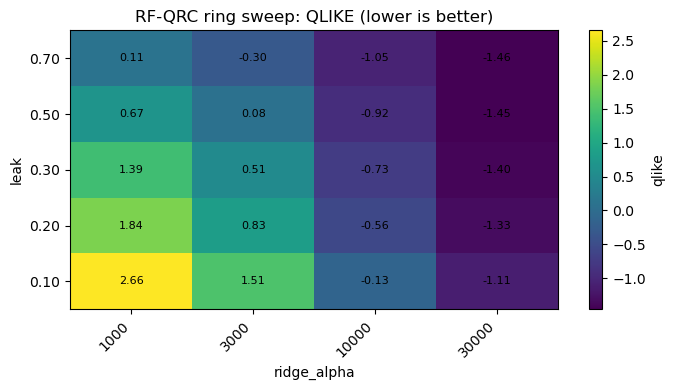

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_qlike_heatmap.png


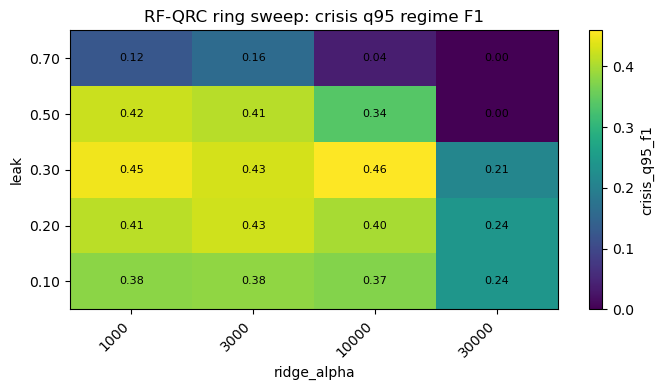

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_crisis_q95_f1_heatmap.png


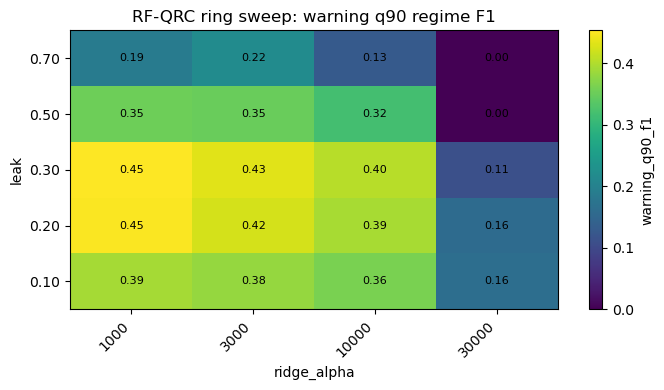

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_warning_q90_f1_heatmap.png


In [12]:
def heatmap_metric(df: pd.DataFrame, metric: str, title: str, filename: str):
    pivot = df.pivot(index="leak", columns="ridge_alpha", values=metric).sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(pivot.values, aspect="auto", origin="lower")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(int(c)) for c in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])
    ax.set_xlabel("ridge_alpha")
    ax.set_ylabel("leak")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=metric)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, dpi=180)
    plt.show()
    print("Saved:", out)

heatmap_metric(sweep, "qlike", "RF-QRC ring sweep: QLIKE (lower is better)", "phase3_rf_qrc_ring_sweep_qlike_heatmap.png")
heatmap_metric(sweep, "crisis_q95_f1", "RF-QRC ring sweep: crisis q95 regime F1", "phase3_rf_qrc_ring_sweep_crisis_q95_f1_heatmap.png")
heatmap_metric(sweep, "warning_q90_f1", "RF-QRC ring sweep: warning q90 regime F1", "phase3_rf_qrc_ring_sweep_warning_q90_f1_heatmap.png")


## 6. Plot best candidate against current baseline

This compares the default current config (`leak=0.30`, `ridge_alpha=3000`) with the best candidate by `selection_score`.


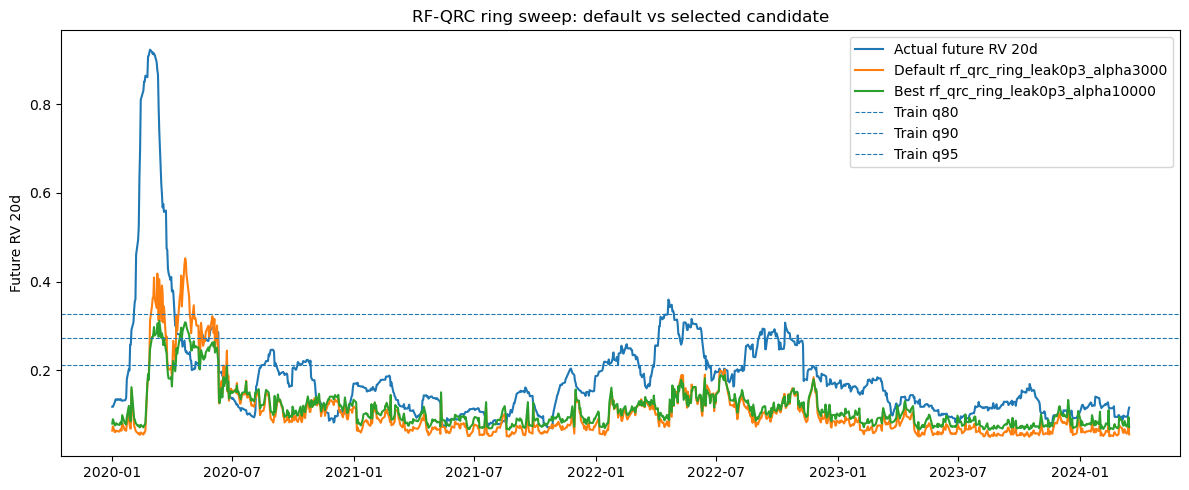

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_default_vs_best.png
Default: rf_qrc_ring_leak0p3_alpha3000
Best: rf_qrc_ring_leak0p3_alpha10000


In [13]:
default_name = "rf_qrc_ring_leak0p3_alpha3000"
best_name = sweep.iloc[0]["run_name"]

plot_df = pred_wide[["date", "actual_future_rv_20d", "split", default_name, best_name]].copy()
plot_df = plot_df[plot_df["split"].eq("test")].merge(
    timeline[["date"]],
    on="date",
    how="inner",
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["date"], plot_df["actual_future_rv_20d"], label="Actual future RV 20d")
ax.plot(plot_df["date"], plot_df[default_name], label=f"Default {default_name}")
ax.plot(plot_df["date"], plot_df[best_name], label=f"Best {best_name}")

for label, thr in [
    ("q80", thresholds["high_vol_q80"]),
    ("q90", thresholds["extreme_vol_q90"]),
    ("q95", thresholds["crisis_candidate_q95"]),
]:
    ax.axhline(thr, linestyle="--", linewidth=0.8, label=f"Train {label}")

ax.set_title("RF-QRC ring sweep: default vs selected candidate")
ax.set_ylabel("Future RV 20d")
ax.legend(loc="upper right")
fig.tight_layout()

out = FIG_DIR / "phase3_rf_qrc_ring_sweep_default_vs_best.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)
print("Default:", default_name)
print("Best:", best_name)


In [14]:
print("Total notebook elapsed:", f"{(time.time() - NOTEBOOK_START)/60:.1f} min")
print("Main output table:", sweep_path)
print("Prediction table:", pred_path)

print("\nNext decision:")
print("- If a guardrail candidate has qlike near -2.0 and crisis_q95_f1 remains > 0.35, use it as calibrated RF-QRC.")
print("- If all good q95 candidates keep bad QLIKE, keep RF-QRC as crisis-warning head and frame the tradeoff.")


Total notebook elapsed: 0.9 min
Main output table: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_metrics.csv
Prediction table: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_predictions.csv

Next decision:
- If a guardrail candidate has qlike near -2.0 and crisis_q95_f1 remains > 0.35, use it as calibrated RF-QRC.
- If all good q95 candidates keep bad QLIKE, keep RF-QRC as crisis-warning head and frame the tradeoff.


In [20]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name != "qpitome-qrc-volatility" and ROOT != ROOT.parent:
    ROOT = ROOT.parent

pred_path = ROOT / "results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_predictions.csv"
metrics_path = ROOT / "results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_metrics.csv"

preds = pd.read_csv(pred_path)
metrics = pd.read_csv(metrics_path)

print("Prediction columns:")
print(preds.columns.tolist())
print("\nMetrics columns:")
print(metrics.columns.tolist())
print("\nPredictions shape:", preds.shape)
print("Metrics shape:", metrics.shape)

Prediction columns:
['date', 'actual_future_rv_20d', 'split', 'rf_qrc_ring_leak0p1_alpha1000', 'rf_qrc_ring_leak0p1_alpha3000', 'rf_qrc_ring_leak0p1_alpha10000', 'rf_qrc_ring_leak0p1_alpha30000', 'rf_qrc_ring_leak0p2_alpha1000', 'rf_qrc_ring_leak0p2_alpha3000', 'rf_qrc_ring_leak0p2_alpha10000', 'rf_qrc_ring_leak0p2_alpha30000', 'rf_qrc_ring_leak0p3_alpha1000', 'rf_qrc_ring_leak0p3_alpha3000', 'rf_qrc_ring_leak0p3_alpha10000', 'rf_qrc_ring_leak0p3_alpha30000', 'rf_qrc_ring_leak0p5_alpha1000', 'rf_qrc_ring_leak0p5_alpha3000', 'rf_qrc_ring_leak0p5_alpha10000', 'rf_qrc_ring_leak0p5_alpha30000', 'rf_qrc_ring_leak0p7_alpha1000', 'rf_qrc_ring_leak0p7_alpha3000', 'rf_qrc_ring_leak0p7_alpha10000', 'rf_qrc_ring_leak0p7_alpha30000']

Metrics columns:
['run_name', 'leak', 'ridge_alpha', 'input_mode', 'n_qubits', 'input_scale', 'feature_seconds_for_leak', 'n_common_test', 'rmse', 'qlike', 'corr', 'actual_std', 'pred_std', 'q80_amplitude_f1', 'q90_amplitude_f1', 'q95_amplitude_f1', 'top20_pred_actua

In [21]:
def repo_qlike(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    target = np.maximum(y_true**2, eps)
    pred = np.maximum(y_pred**2, eps)

    return float(np.mean(np.log(pred) + target / pred))


def parse_leak_alpha(text):
    text = str(text)

    # Handles leak0p3_alpha3000, leak0.3_alpha3000, leak_0p3_alpha_3000, etc.
    m = re.search(r"leak[_-]?([0-9]+(?:p|\.|_)[0-9]+).*?alpha[_-]?([0-9]+)", text)
    if m:
        leak = float(m.group(1).replace("p", ".").replace("_", "."))
        alpha = float(m.group(2))
        return leak, alpha

    return np.nan, np.nan


# Test rows only
if "split" in preds.columns:
    test = preds[preds["split"].astype(str).str.lower().eq("test")].copy()
else:
    test = preds.copy()

actual_col = "actual_future_rv_20d"
if actual_col not in test.columns:
    raise KeyError(f"Missing {actual_col}. Available columns: {test.columns.tolist()}")

y = test[actual_col].to_numpy(dtype=float)

metadata_cols = {
    "date",
    "split",
    "run_name",
    "actual_future_rv_20d",
    "future_rv_20d",
}

candidate_pred_cols = [
    c for c in test.columns
    if c not in metadata_cols
    and pd.api.types.is_numeric_dtype(test[c])
]

print("Detected prediction columns:")
print(candidate_pred_cols)

qlike_rows = []
for col in candidate_pred_cols:
    leak, alpha = parse_leak_alpha(col)
    qlike_rows.append({
        "prediction_column": col,
        "run_name": col.removesuffix("_pred") if hasattr(str, "removesuffix") else col.replace("_pred", ""),
        "leak": leak,
        "ridge_alpha": alpha,
        "qlike_repo": repo_qlike(y, test[col].to_numpy(dtype=float)),
    })

qlike_fix = pd.DataFrame(qlike_rows)

if qlike_fix.empty:
    raise ValueError("No prediction columns detected. Check printed columns above.")

display(qlike_fix.sort_values("qlike_repo"))

Detected prediction columns:
['rf_qrc_ring_leak0p1_alpha1000', 'rf_qrc_ring_leak0p1_alpha3000', 'rf_qrc_ring_leak0p1_alpha10000', 'rf_qrc_ring_leak0p1_alpha30000', 'rf_qrc_ring_leak0p2_alpha1000', 'rf_qrc_ring_leak0p2_alpha3000', 'rf_qrc_ring_leak0p2_alpha10000', 'rf_qrc_ring_leak0p2_alpha30000', 'rf_qrc_ring_leak0p3_alpha1000', 'rf_qrc_ring_leak0p3_alpha3000', 'rf_qrc_ring_leak0p3_alpha10000', 'rf_qrc_ring_leak0p3_alpha30000', 'rf_qrc_ring_leak0p5_alpha1000', 'rf_qrc_ring_leak0p5_alpha3000', 'rf_qrc_ring_leak0p5_alpha10000', 'rf_qrc_ring_leak0p5_alpha30000', 'rf_qrc_ring_leak0p7_alpha1000', 'rf_qrc_ring_leak0p7_alpha3000', 'rf_qrc_ring_leak0p7_alpha10000', 'rf_qrc_ring_leak0p7_alpha30000']


,prediction_column,run_name,leak,ridge_alpha,qlike_repo
19,rf_qrc_ring_leak0p7_alpha30000,rf_qrc_ring_leak0p7_alpha30000,0.7,30000.0,-1.610839
15,rf_qrc_ring_leak0p5_alpha30000,rf_qrc_ring_leak0p5_alpha30000,0.5,30000.0,-1.602214
11,rf_qrc_ring_leak0p3_alpha30000,rf_qrc_ring_leak0p3_alpha30000,0.3,30000.0,-1.561447
7,rf_qrc_ring_leak0p2_alpha30000,rf_qrc_ring_leak0p2_alpha30000,0.2,30000.0,-1.494360
3,rf_qrc_ring_leak0p1_alpha30000,rf_qrc_ring_leak0p1_alpha30000,0.1,30000.0,-1.287466
18,rf_qrc_ring_leak0p7_alpha10000,rf_qrc_ring_leak0p7_alpha10000,0.7,10000.0,-1.236331
14,rf_qrc_ring_leak0p5_alpha10000,rf_qrc_ring_leak0p5_alpha10000,0.5,10000.0,-1.113348
10,rf_qrc_ring_leak0p3_alpha10000,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,-0.940486
6,rf_qrc_ring_leak0p2_alpha10000,rf_qrc_ring_leak0p2_alpha10000,0.2,10000.0,-0.779479
17,rf_qrc_ring_leak0p7_alpha3000,rf_qrc_ring_leak0p7_alpha3000,0.7,3000.0,-0.537646


In [22]:
metrics_fixed = metrics.copy()

# Add leak/alpha to metrics if missing
if "leak" not in metrics_fixed.columns or "ridge_alpha" not in metrics_fixed.columns:
    if "run_name" in metrics_fixed.columns:
        parsed = metrics_fixed["run_name"].apply(parse_leak_alpha)
        metrics_fixed["leak"] = [x[0] for x in parsed]
        metrics_fixed["ridge_alpha"] = [x[1] for x in parsed]
    else:
        raise KeyError("Metrics table has neither leak/ridge_alpha nor run_name.")

# Merge by leak/alpha, not by exact run_name
metrics_fixed = metrics_fixed.merge(
    qlike_fix[["leak", "ridge_alpha", "qlike_repo"]],
    on=["leak", "ridge_alpha"],
    how="left",
)

metrics_fixed.to_csv(
    ROOT / "results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_metrics_FIXED_QLIKE.csv",
    index=False,
)

display(metrics_fixed.sort_values("qlike_repo").head(20))

,run_name,leak,ridge_alpha,input_mode,n_qubits,input_scale,feature_seconds_for_leak,n_common_test,rmse,qlike,corr,actual_std,pred_std,q80_amplitude_f1,q90_amplitude_f1,q95_amplitude_f1,top20_pred_actual_ratio,watch_q80_f1,watch_q80_precision,watch_q80_recall,warning_q90_f1,warning_q90_precision,warning_q90_recall,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,crisis_q95_tp,crisis_q95_fp,crisis_q95_fn,selection_score,qlike_repo
17,rf_qrc_ring_leak0p7_alpha30000,0.7,30000.0,level_rate,6,1.047198,9.186330,1058,0.128825,-1.457864,0.423733,0.124367,0.021748,0.000000,0.000000,0.000000,0.214154,0.548837,0.465789,0.667925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,51,0.130752,-1.610839
16,rf_qrc_ring_leak0p5_alpha30000,0.5,30000.0,level_rate,6,1.047198,9.482539,1058,0.128137,-1.446568,0.478200,0.124367,0.024983,0.000000,0.000000,0.000000,0.230134,0.548837,0.465789,0.667925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,51,0.139951,-1.602214
7,rf_qrc_ring_leak0p3_alpha30000,0.3,30000.0,level_rate,6,1.047198,13.437730,1058,0.127967,-1.401085,0.524309,0.124367,0.027308,0.100358,0.000000,0.000000,0.245991,0.555556,0.469974,0.679245,0.111111,0.571429,0.061538,0.210526,1.000000,0.117647,0.005671,6,0,45,0.392773,-1.561447
6,rf_qrc_ring_leak0p2_alpha30000,0.2,30000.0,level_rate,6,1.047198,9.837434,1058,0.128556,-1.328219,0.523403,0.124367,0.028572,0.146853,0.000000,0.000000,0.260743,0.560000,0.472727,0.686792,0.158940,0.571429,0.092308,0.241379,1.000000,0.137255,0.006616,7,0,44,0.429922,-1.494360
9,rf_qrc_ring_leak0p1_alpha30000,0.1,30000.0,level_rate,6,1.047198,10.805012,1058,0.131709,-1.105466,0.456477,0.124367,0.028743,0.120567,0.015267,0.000000,0.261499,0.555556,0.469974,0.679245,0.163265,0.705882,0.092308,0.241379,1.000000,0.137255,0.006616,7,0,44,0.383971,-1.287466
15,rf_qrc_ring_leak0p7_alpha10000,0.7,10000.0,level_rate,6,1.047198,9.186330,1058,0.129990,-1.049936,0.441265,0.124367,0.036097,0.158621,0.000000,0.000000,0.266120,0.565749,0.475578,0.698113,0.129032,0.400000,0.076923,0.038462,1.000000,0.019608,0.000945,1,0,50,0.159229,-1.236331
2,rf_qrc_ring_leak0p5_alpha10000,0.5,10000.0,level_rate,6,1.047198,9.482539,1058,0.128737,-0.917749,0.502844,0.124367,0.042217,0.301887,0.014815,0.000000,0.301899,0.578788,0.483544,0.720755,0.316940,0.547170,0.223077,0.338462,0.785714,0.215686,0.013233,11,3,40,0.519440,-1.113348
0,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,level_rate,6,1.047198,13.437730,1058,0.128624,-0.732825,0.541648,0.124367,0.047045,0.359756,0.171053,0.000000,0.333812,0.586103,0.488665,0.732075,0.404145,0.619048,0.300000,0.459459,0.739130,0.333333,0.021739,17,6,34,0.652079,-0.940486
1,rf_qrc_ring_leak0p2_alpha10000,0.2,10000.0,level_rate,6,1.047198,9.837434,1058,0.129924,-0.560889,0.533774,0.124367,0.049608,0.353659,0.165605,0.210526,0.362546,0.583964,0.487374,0.728302,0.393782,0.603175,0.292308,0.400000,0.625000,0.294118,0.022684,15,9,36,0.561306,-0.779479
14,rf_qrc_ring_leak0p7_alpha3000,0.7,3000.0,level_rate,6,1.047198,9.186330,1058,0.132811,-0.302549,0.437903,0.124367,0.047846,0.233010,0.057554,0.000000,0.327029,0.569254,0.477041,0.705660,0.218391,0.431818,0.146154,0.161290,0.454545,0.098039,0.010397,5,6,46,0.201078,-0.537646


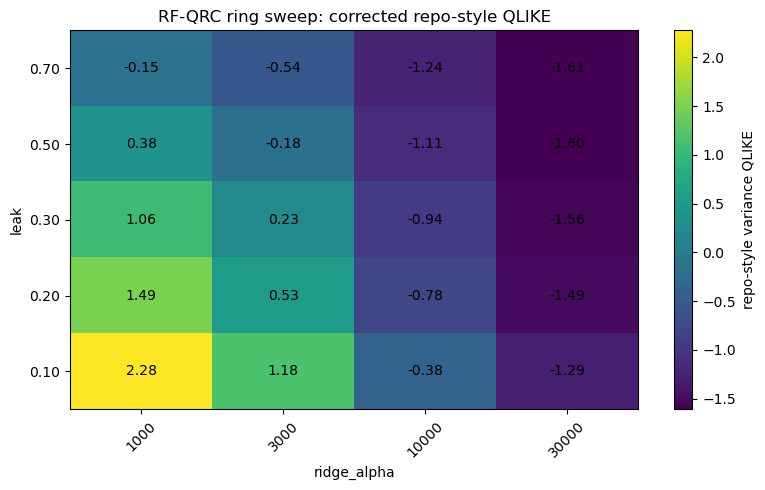

In [23]:
import matplotlib.pyplot as plt

pivot = metrics_fixed.pivot_table(
    index="leak",
    columns="ridge_alpha",
    values="qlike_repo",
    aggfunc="mean",
).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(int(c)) for c in pivot.columns], rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])

ax.set_xlabel("ridge_alpha")
ax.set_ylabel("leak")
ax.set_title("RF-QRC ring sweep: corrected repo-style QLIKE")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="repo-style variance QLIKE")
plt.tight_layout()
plt.show()